# Importing packages

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import sys
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from pprint import pprint
from sklearn import set_config
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor, VotingRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Environment

In [3]:
print("Environment :")
print("=" * 50)

print("Python :", sys.version)
print("Numpy :", np.__version__)
print("Pandas :", pd.__version__)

Environment :
Python : 3.10.14 (main, May  6 2024, 19:42:50) [GCC 11.2.0]
Numpy : 2.2.6
Pandas : 2.3.3


# Configurations & Constants

In [8]:
# Configurations
plt.rcParams["figure.figsize"] = (12, 8)
set_config(display = "diagram")
warnings.filterwarnings("ignore")

# Constants
RANDOM_STATE = 42
SUBMISSION_CSV_PATH = "submission.csv"
SAMPLE_SUBMISSION_CSV_PATH = "sample_submission.csv"
TEST_CSV_PATH = "test.csv"
TRAIN_CSV_PATH = "real_train.csv"

In [9]:
# reading data from files
train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

# Looking into the dataset

In [10]:
# shapes of train and test datasets
train_df.shape, test_df.shape

((10000, 17), (1500, 17))

In [11]:
# sampling the train dataset
train_df.sample(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
6863,1,2023-06-28 18:35:06,2023-06-28 18:07:41,1.0,1.24,1.0,N,256,112,Cash,2.5,3.369521,0.0,1.0,15.10,2.5,0.0
9521,0,2023-06-30 22:36:26,2023-06-30 22:12:24,1.0,1.70,1.0,N,19,79,Credit Card,3.5,5.612290,0.0,1.0,13.00,2.5,0.0
6351,0,2023-06-30 14:08:36,2023-06-30 13:56:53,3.0,2.00,1.0,N,109,188,Credit Card,2.5,3.695934,0.0,1.0,19.75,2.5,0.0
8334,1,2023-06-29 12:29:11,2023-06-29 14:16:59,1.0,1.72,1.0,N,133,204,Cash,0.0,4.655567,0.0,1.0,17.50,2.5,0.0
8724,1,2023-06-29 17:22:08,2023-06-29 18:43:07,NaN,3.82,NaN,NaN,40,131,Wallet,0.0,9.900768,0.0,1.0,45.36,NaN,NaN


In [12]:
# sampling the test dataset
test_df.sample(5)

,id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee
1386,1386,1,2023-06-28 23:28:40,2023-06-28 23:36:41,NaN,4.08,NaN,NaN,27,255,Wallet,0.0,6.707452,0.00,1.0,NaN,NaN
785,785,0,2023-06-30 09:45:37,2023-06-30 08:59:49,1.0,1.10,1.0,N,187,128,Cash,2.5,4.903296,0.00,1.0,2.5,0.0
701,701,1,2023-06-28 20:43:25,2023-06-28 22:11:00,1.0,5.83,1.0,N,3,210,Credit Card,1.0,9.379250,6.55,1.0,2.5,0.0
1146,1146,1,2023-06-28 17:47:19,2023-06-28 18:08:23,1.0,1.65,1.0,N,161,79,Credit Card,2.5,4.296019,0.00,1.0,2.5,0.0
257,257,1,2023-06-29 10:33:57,2023-06-29 11:37:13,1.0,2.02,1.0,N,117,119,Credit Card,0.0,7.699499,0.00,1.0,2.5,0.0


In [13]:
for col in train_df.columns:
    n = train_df[col].nunique()
    print(f"Column: {col} has {n} unique values.")
    print(train_df[col].value_counts())
    print("-" * 40)

Column: VendorID has 3 unique values.
VendorID
1    7289
0    2710
2       1
Name: count, dtype: int64
----------------------------------------
Column: tpep_pickup_datetime has 9740 unique values.
tpep_pickup_datetime
2023-06-29 12:28:44    3
2023-06-30 13:01:18    3
2023-06-28 18:30:23    3
2023-06-28 17:50:25    3
2023-06-30 16:52:44    3
                      ..
2023-06-29 08:32:47    1
2023-06-30 02:14:21    1
2023-06-30 18:04:03    1
2023-06-30 10:15:22    1
2023-06-28 17:43:32    1
Name: count, Length: 9740, dtype: int64
----------------------------------------
Column: tpep_dropoff_datetime has 9744 unique values.
tpep_dropoff_datetime
2023-06-29 11:57:01    3
2023-06-29 20:28:44    3
2023-06-29 22:32:55    3
2023-06-28 17:42:52    3
2023-06-29 22:49:33    2
                      ..
2023-06-30 16:00:56    1
2023-06-30 09:11:17    1
2023-06-29 12:05:50    1
2023-06-29 08:50:40    1
2023-06-30 11:52:51    1
Name: count, Length: 9744, dtype: int64
-----------------------------------

### Observations from Column Value Analysis

- `VendorID` : Contains values **0, 1, and 2**. VendorID should normally represent valid vendor identifiers, so **0 may indicate invalid or missing data** and should be investigated or replaced.

- `tpep_pickup_datetime` : Has **9740 unique values**, meaning most rows represent unique pickup times. The column is currently stored as **object type** and should be **converted to datetime** for time-based analysis.

- `tpep_dropoff_datetime` : Has **9744 unique values** and is also stored as **object type**. It should be **converted to datetime** to enable trip duration calculations.

- `passenger_count` : Contains **0 passengers**, which is **not realistic for a taxi trip**. Replace **0 values with the mode (most common value = 1)** or treat them as missing values.

- `trip_distance` : Includes **0.00 distance values**, which are **unlikely for a completed trip**. These rows may represent **data entry errors or cancelled trips** and should be handled appropriately (remove or investigate).

- `RatecodeID` : Contains **value 99**, which is typically used as **unknown or invalid rate code**. Consider treating this value as **missing data**.

- `store_and_fwd_flag` : Only **Y and N values** appear, which is expected. However, the column contains **missing values (since only 9634 non-null earlier)** and they should be filled or handled.

- `PULocationID` : Contains **264 unique pickup locations**, indicating a wide geographic distribution of trip origins.

- `DOLocationID` : Contains **264 unique drop-off locations**, suggesting trips are distributed across many destinations.

- `payment_type` : Includes **"unknown" values**, which represent **unclear payment methods** and may need cleaning or grouping with missing values.

- `extra` : Contains **negative values (e.g., -1.00, -2.50, -5.00, -7.50)**. Extra charges should generally **not be negative**, indicating possible **data inconsistencies**.

- `tip_amount` : Every value is **unique (10000 unique values)**, suggesting tips were generated with **high precision values**. This is unusual for real-world taxi tips and may indicate **synthetic or simulated data**.

- `tolls_amount` : Mostly **0.00**, which is reasonable since most trips may not involve toll roads. However, **negative toll values exist**, which should be **treated as data errors and corrected or removed**.

- `improvement_surcharge` : Includes **negative (-1.0) and unusual values (0.3)**. The surcharge should typically be **1.0**, so other values likely represent **incorrect entries**.

- `total_amount` : Has **2193 unique values**, which is reasonable as trip fares vary widely.

- `congestion_surcharge` : Includes **negative values (-2.5)** which are **invalid for surcharges**. These should be corrected or treated as missing.

- `Airport_fee` : Contains **negative values (-1.75)** which are **invalid**, since airport fees should not be negative. These values should be cleaned or replaced.

In [319]:
for col in test_df.columns:
    n = test_df[col].nunique()
    print(f"Column: {col} has {n} unique values.")
    print(test_df[col].value_counts())
    print("-" * 40)

Column: id has 1500 unique values.
id
1499    1
0       1
1       1
2       1
3       1
       ..
16      1
15      1
14      1
13      1
12      1
Name: count, Length: 1500, dtype: int64
----------------------------------------
Column: VendorID has 3 unique values.
VendorID
1    1084
0     415
2       1
Name: count, dtype: int64
----------------------------------------
Column: tpep_pickup_datetime has 1493 unique values.
tpep_pickup_datetime
2023-06-28 18:30:56    2
2023-06-29 10:15:09    2
2023-06-28 22:01:21    2
2023-06-30 17:35:10    2
2023-06-29 13:43:03    2
                      ..
2023-06-30 16:50:17    1
2023-06-29 15:45:05    1
2023-06-29 12:00:47    1
2023-06-29 06:49:22    1
2023-06-29 09:59:21    1
Name: count, Length: 1493, dtype: int64
----------------------------------------
Column: tpep_dropoff_datetime has 1495 unique values.
tpep_dropoff_datetime
2023-06-29 16:03:38    2
2023-06-29 12:09:22    2
2023-06-29 08:53:45    2
2023-06-29 19:48:16    2
2023-06-28 22:11:00  

### Observations from Test Dataset

- `id` : Unique identifier for each row (**1500 unique values for 1500 rows**). This column acts as a **primary key** and should not be used for modeling.

- `VendorID` : Contains values **0, 1, and 2**. Similar to the training data, **0 may represent invalid or missing vendor information** and should be investigated or treated as missing.

- `tpep_pickup_datetime` : Stored as **object type** and should be **converted to datetime** to enable time-based feature engineering such as hour, day, and trip duration.

- `tpep_dropoff_datetime` : Also stored as **object type** and should be **converted to datetime** for calculating **trip duration**.

- `passenger_count` : Contains **0 passengers**, which is **not realistic for a taxi trip**. Replace **0 values with the mode (1)** or treat them as missing.

- `trip_distance` : No obvious invalid values, but should still be checked for **zero or extremely large distances** during cleaning.

- `RatecodeID` : Includes **value 99**, which typically represents **unknown or undefined rate code** and should be treated as **missing or categorized separately**.

- `store_and_fwd_flag` : Contains **Y and N values**, which is expected. However, the earlier dataset showed missing values, so consistency should be checked.

- `PULocationID` : **264 unique pickup locations**, indicating trips originate from many different zones.

- `DOLocationID` : **264 unique drop-off locations**, showing a wide spread of destinations.

- `payment_type` : Includes **"unknown" values**, which should be treated as **missing or grouped into an "other" category**.

- `extra` : Contains **negative values (-1.00, -2.50, -5.00)**, which are **not realistic for extra charges** and likely represent **data errors**.

- `tip_amount` : Every value is **unique (1500 unique values)**, which is unusual for real taxi data and suggests **high precision or synthetic data generation**.

- `tolls_amount` : Mostly **0**, which is expected, but **negative values (-6.55)** appear and should be **corrected or treated as invalid**.

- `improvement_surcharge` : Mostly **1.0**, but includes **-1.0 and other unusual values**, which likely represent **incorrect entries**.

- `congestion_surcharge` : Contains **negative values (-2.5)**, which are **invalid for surcharges** and should be corrected or treated as missing.

- `Airport_fee` : Includes **negative values (-1.75)**, which are **not valid airport fees** and should be cleaned.

---

### Key Differences Compared to Training Dataset

- The **test dataset includes an additional `id` column** used to uniquely identify rows.
- The **test dataset has fewer rows (1500 vs 10000)** but maintains a **similar distribution and structure** of features.
- Data quality issues (negative surcharges, zero passengers, unknown categories) are **consistent with the training dataset**, meaning **the same cleaning steps can be applied to both datasets**.

# Data types of the different columns

In [320]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

### Data Types of Columns in the Dataset

The dataset contains **17 columns** with the following data types:

**Summary of data types:**
- **int64:** 3 columns  
- **float64:** 10 columns  
- **object:** 4 columns  

The datetime columns (`tpep_pickup_datetime` and `tpep_dropoff_datetime`) are currently stored as **object (string)** type and can be converted to **datetime** format if needed for time-based analysis.

# Descriptive statistics of numerical columns

In [321]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorID,10000.0,0.729100,0.444672,0.000000,0.000000,1.000000,1.000000,2.000000
passenger_count,9634.0,1.357276,0.883676,0.000000,1.000000,1.000000,1.000000,6.000000
trip_distance,10000.0,3.679527,4.905798,0.000000,1.070000,1.820000,3.630000,71.940000
RatecodeID,9634.0,1.450695,5.988978,1.000000,1.000000,1.000000,1.000000,99.000000
PULocationID,10000.0,132.710800,75.789597,1.000000,67.000000,133.000000,198.000000,264.000000
DOLocationID,10000.0,132.332400,75.959440,1.000000,68.000000,132.000000,199.000000,264.000000
extra,10000.0,1.940950,1.945885,-7.500000,0.000000,1.750000,2.500000,11.750000
tip_amount,10000.0,6.094658,4.438894,0.000713,3.466789,5.208233,7.455228,84.032617
tolls_amount,10000.0,0.664425,2.441070,-26.550000,0.000000,0.000000,0.000000,32.050000
improvement_surcharge,10000.0,0.979490,0.200076,-1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1500.0,749.500000,433.157015,0.000000,374.750000,749.500000,1124.250000,1499.000000
VendorID,1500.0,0.724000,0.448655,0.000000,0.000000,1.000000,1.000000,2.000000
passenger_count,1445.0,1.347405,0.893809,0.000000,1.000000,1.000000,1.000000,6.000000
trip_distance,1500.0,3.774533,4.895958,0.000000,1.137500,1.880000,3.902500,45.490000
RatecodeID,1445.0,1.687197,7.715986,1.000000,1.000000,1.000000,1.000000,99.000000
PULocationID,1500.0,131.562667,76.375766,1.000000,68.000000,131.000000,200.000000,264.000000
DOLocationID,1500.0,131.780000,76.044189,1.000000,65.000000,130.000000,198.000000,264.000000
extra,1500.0,1.935500,2.012937,-5.000000,0.000000,1.000000,2.500000,11.750000
tip_amount,1500.0,6.132381,4.102919,0.001095,3.545985,5.227615,7.605167,26.711745
tolls_amount,1500.0,0.620073,2.187539,-6.550000,0.000000,0.000000,0.000000,29.560000


### Observations from Descriptive Statistics (Training Dataset)

- `VendorID` : Mean value is **0.73** with values ranging from **0 to 2**. Since VendorID is a categorical identifier, statistical measures like mean are **not meaningful**. The presence of **0 suggests possible invalid or missing vendor entries**.

- `passenger_count` : Minimum value is **0**, which is **not realistic for taxi trips**. Most trips have **1 passenger (median = 1)**, indicating that single-passenger rides dominate the dataset. Zero values should be **replaced with the mode (1) or treated as missing**.

- `trip_distance` : Minimum value is **0**, suggesting **possible cancelled or incorrectly recorded trips**. The maximum distance is **71.94 miles**, which is **much larger than the 75th percentile (3.63)**, indicating the presence of **significant outliers**.

- `RatecodeID` : Median and quartiles are **1**, meaning most trips use the **standard rate code**. However, the maximum value **99** is unusual and likely represents **unknown or invalid rate codes**.

- `PULocationID` and `DOLocationID` : Both range from **1 to 264**, representing location zones. Since these are **categorical geographic identifiers**, descriptive statistics like mean and standard deviation **do not provide meaningful insights**.

- `extra` : Contains **negative values (-7.5)**, which should not occur for extra charges. This indicates **data entry errors or adjustments that need cleaning**.

- `tip_amount` : Mean tip is **6.09** with a maximum of **84.03**, which is **extremely high compared to the 75th percentile (7.45)**, suggesting the presence of **outliers**.

- `tolls_amount` : Mostly **0** (since median and 75th percentile are 0), meaning most trips did not involve toll roads. However, **negative values (-26.55)** appear, which are **invalid and should be corrected**.

- `improvement_surcharge` : Mostly **1.0**, which aligns with the standard surcharge value. However, the presence of **-1 values indicates incorrect entries**.

- `total_amount` : Minimum value is **-129.3**, which is **not realistic for a taxi fare** and suggests **refunds, data errors, or incorrect records**. The maximum **551** is also significantly higher than the 75th percentile **31.8**, indicating **extreme outliers**.

- `congestion_surcharge` : Most values are **2.5**, indicating a standard congestion fee. However, **negative values (-2.5)** exist and should be treated as **invalid data**.

- `Airport_fee` : Mostly **0**, meaning most trips did not include an airport fee. However, **negative values (-1.75)** appear, which are **not valid and should be cleaned**.

### Overall Insights
- Several columns contain **invalid negative values** (e.g., `extra`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, `Airport_fee`).
- Some columns contain **unrealistic values** such as **0 passengers** or **negative total fares**.
- There are **significant outliers** in `trip_distance`, `tip_amount`, and `total_amount`.
- Some columns represent **categorical identifiers** (`VendorID`, `RatecodeID`, `PULocationID`, `DOLocationID`) where statistical summaries are **not very informative** and should be treated as categorical features during modeling.

# Looking for missing values

In [322]:
train_df.isna().sum()

VendorID                   0
tpep_pickup_datetime       0
tpep_dropoff_datetime      0
passenger_count          366
trip_distance              0
RatecodeID               366
store_and_fwd_flag       366
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     366
Airport_fee              366
dtype: int64

### Observations from Missing Values

- `passenger_count` : **366 missing values**. This should ideally be recorded for every trip. Missing values can be **imputed using the mode (most common value = 1)**.

- `RatecodeID` : **366 missing values**. Since rate codes represent fare categories, these missing values should be **filled with the most frequent value (likely 1 – standard rate)** or treated as a separate category.

- `store_and_fwd_flag` : **366 missing values**. This flag indicates whether trip data was stored in the vehicle before sending to the server. Missing values can be **filled with the mode (`N`)**.

- `congestion_surcharge` : **366 missing values**. Since this is a standard surcharge in certain zones, missing values can be **filled with the most common value (2.5 or 0 depending on context)**.

- `Airport_fee` : **366 missing values**. Since most trips do not involve airports, missing values can likely be **filled with 0**.

### Summary
- A total of **5 columns contain missing values**:  
  `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `Airport_fee`.

- Each of these columns has **366 missing entries**, suggesting the missing data may come from **specific rows where multiple related fields were not recorded**.

- These missing values will be **handled during preprocessing using a `SimpleImputer` inside an sklearn `Pipeline`, ensuring consistent treatment during both training and inference**.

In [323]:
train_df["passenger_count"] = train_df["passenger_count"].replace(0, np.nan)

### Handling Invalid Passenger Counts

Some records in the dataset contained a passenger count of 0, which is not logically valid for a taxi trip. These values were replaced with NaN so they can be properly handled during preprocessing using imputation techniques in the machine learning pipeline.

# Looking for the duplicates

In [324]:
train_df.duplicated().sum()

np.int64(0)

**No duplicates are found**

# Correlation matrix

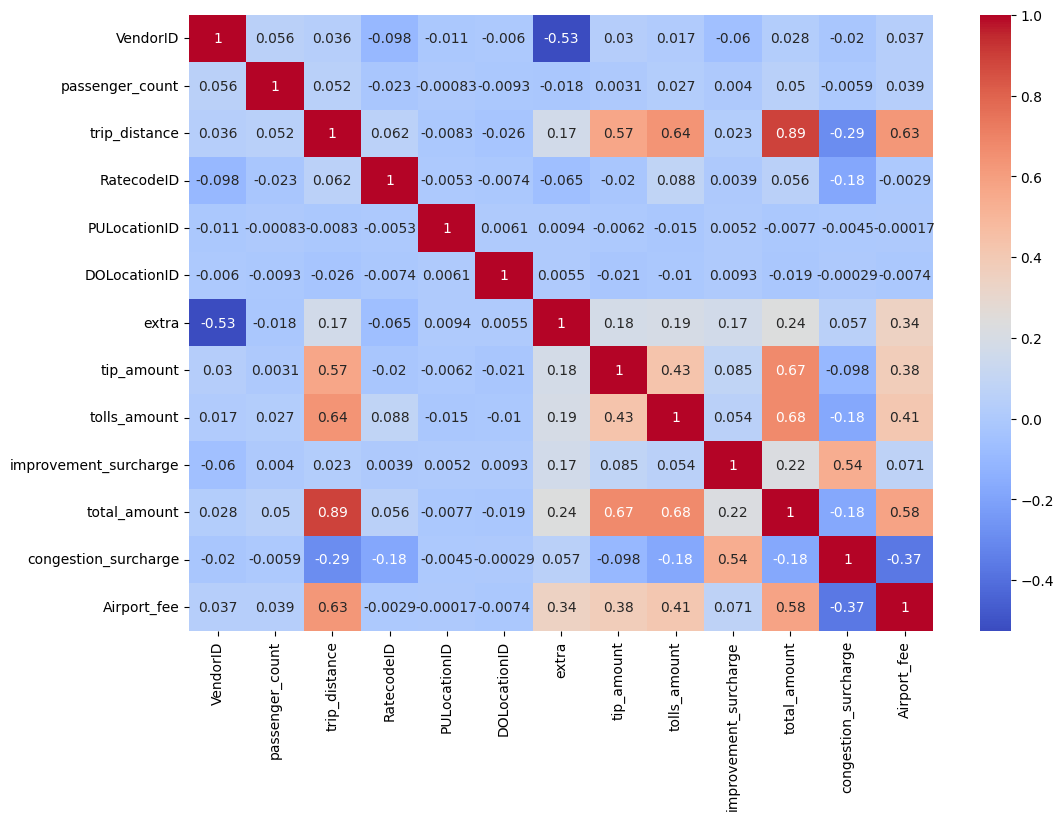

In [325]:
corr_mat = train_df.corr(numeric_only = True)

sns.heatmap(
    corr_mat,
    annot = True,
    cmap = "coolwarm"
)
plt.show()

### Observations from the Correlation Matrix

- `trip_distance` shows a **very strong positive correlation with `total_amount` (0.89)**. This is expected because longer trips generally result in higher fares.

- `tip_amount` has a **strong positive correlation with `total_amount` (0.67)** and a **moderate correlation with `trip_distance` (0.56)**. This suggests that passengers tend to give higher tips on longer or more expensive trips.

- `tolls_amount` is **strongly correlated with `total_amount` (0.68)** and **trip_distance (0.64)**, indicating that longer trips are more likely to include toll charges.

- `Airport_fee` has a **moderate correlation with `trip_distance` (0.63)** and **total_amount (0.58)**. This suggests that trips involving airports tend to be longer and cost more.

- `extra` shows **moderate correlations with `Airport_fee` (0.34)** and **total_amount (0.24)**, indicating that additional charges often contribute to higher overall fares.

- `improvement_surcharge` has a **moderate positive correlation with `congestion_surcharge` (0.54)**, likely because both are fixed surcharges applied under certain trip conditions.

- `congestion_surcharge` has a **moderate negative correlation with `trip_distance` (-0.29)** and **Airport_fee (-0.37)**, suggesting congestion fees may be more common in shorter urban trips rather than longer airport trips.

- `VendorID` has a **strong negative correlation with `extra` (-0.53)**, which may indicate that different vendors apply extra charges differently.

- `passenger_count` shows **very weak correlations with most variables**, indicating that the number of passengers does not strongly influence trip cost or distance.

- `PULocationID` and `DOLocationID` have **near-zero correlation with other features**, which is expected because these are **categorical location identifiers rather than numerical quantities**.

### Key Insights
- **`trip_distance`, `tip_amount`, `tolls_amount`, and `Airport_fee` are strong predictors of `total_amount`.**
- Several surcharge-related features contribute moderately to the final fare.
- Location IDs behave like categorical variables and therefore show **little linear correlation** with other numerical features.

# Identifying the outliers

In [326]:
num_cols = train_df.select_dtypes(include=['int64','float64']).columns
outlier_summary = {}

for col in num_cols:
    
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
    
    outlier_summary[col] = len(outliers)

print("Outliers in each column:")
pprint(outlier_summary)

Outliers in each column:
{'Airport_fee': 909,
 'DOLocationID': 0,
 'PULocationID': 0,
 'RatecodeID': 577,
 'VendorID': 0,
 'congestion_surcharge': 923,
 'extra': 242,
 'improvement_surcharge': 106,
 'passenger_count': 2179,
 'tip_amount': 657,
 'tolls_amount': 884,
 'total_amount': 1343,
 'trip_distance': 1354}


## Outlier Detection Observations

Outliers were detected using the **Interquartile Range (IQR) method** for all numerical columns in the dataset. The following observations were made based on the number of detected outliers:

### Columns with High Number of Outliers
- **trip_distance (1354 outliers)**  
  A large number of outliers exist in trip distance. This may represent unusually long taxi trips or potential data entry errors.

- **total_amount (1343 outliers)**  
  The total fare amount has many extreme values. These may correspond to long-distance trips, airport trips, or unusually high charges.

- **tip_amount (657 outliers)**  
  Tip values vary significantly. High tips may occur for expensive trips or generous customers.

- **tolls_amount (884 outliers)**  
  Outliers in toll amounts may correspond to trips passing through toll roads or bridges.

- **extra (242 outliers)**  
  Extra charges such as peak-hour fees or night charges can create outliers.

### Columns with Moderate Outliers
- **improvement_surcharge (106 outliers)**  
  This surcharge is generally fixed, but small deviations exist in the dataset.

### Columns Treated as Categorical Variables
The following columns were identified as **categorical features**, meaning they represent categories or codes rather than continuous numerical values. Because of this, the detected “outliers” do not represent true anomalies but rather **class imbalance or uneven category distribution**.

- VendorID  
- passenger_count  
- RatecodeID  
- PULocationID  
- DOLocationID  
- Airport_fee  
- congestion_surcharge  
- improvement_surcharge  

For these variables, the large number of detected outliers does **not necessarily indicate incorrect data**, but rather reflects that certain categories appear much more frequently than others.

### Key Insight
Most meaningful outliers appear in **continuous numerical variables related to trip cost and distance**, such as:
- trip_distance
- total_amount
- tip_amount
- tolls_amount

These columns should be carefully analyzed before deciding whether to remove or cap extreme values, as some outliers may represent **valid long-distance or high-fare taxi trips**.

In [327]:
outlier_cols = [
    "trip_distance",
    "tip_amount",
    "tolls_amount",
    "extra",
    "total_amount"
]

outlier_summary = {}

# mask to track rows with any outlier
any_outlier_mask = np.zeros(len(train_df), dtype=bool)

for col in outlier_cols:
    
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    col_outliers = (train_df[col] < lower) | (train_df[col] > upper)
    
    # count outliers
    outlier_summary[col] = col_outliers.sum()
    
    # update row mask
    any_outlier_mask |= col_outliers

print("Outliers in each column:")
pprint(outlier_summary)

# rows containing at least one outlier
rows_with_outliers = any_outlier_mask.sum()

print("\nRows containing at least one outlier:", rows_with_outliers)

Outliers in each column:
{'extra': np.int64(242),
 'tip_amount': np.int64(657),
 'tolls_amount': np.int64(884),
 'total_amount': np.int64(1343),
 'trip_distance': np.int64(1354)}

Rows containing at least one outlier: 1605


## Outlier Handling Strategy

Outlier analysis revealed that 1605 rows contained at least one statistical outlier using the IQR method.

However, in transportation datasets such as taxi trip records, extreme values may represent legitimate scenarios such as long-distance trips, airport rides, or high toll charges.

Therefore, instead of removing all outlier rows, the following strategy was adopted:

1. Logically impossible values such as negative distances and negative fare components were removed.
2. Extreme numerical values were capped using the IQR-based Winsorization technique.
3. Categorical columns were excluded from outlier analysis as their extreme values represent category imbalance rather than true anomalies.

This approach preserves valuable data while reducing the impact of extreme values on model performance.

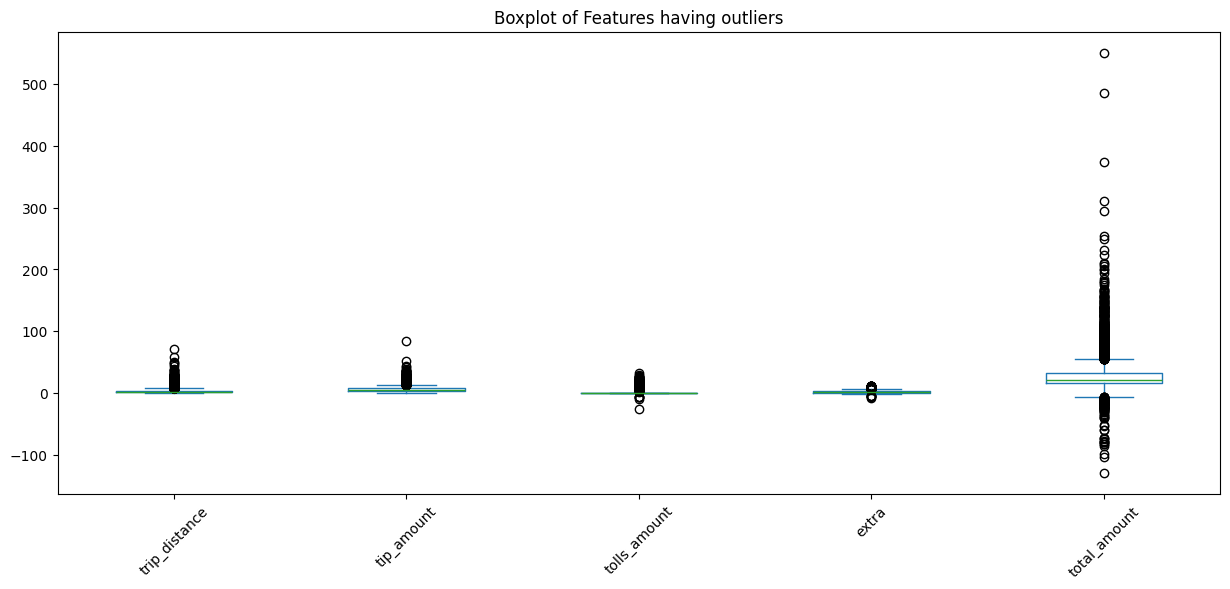

In [328]:
# Plot boxplots
train_df[outlier_cols].plot(kind='box', figsize=(15,6), rot=45)

plt.title("Boxplot of Features having outliers")
plt.show()

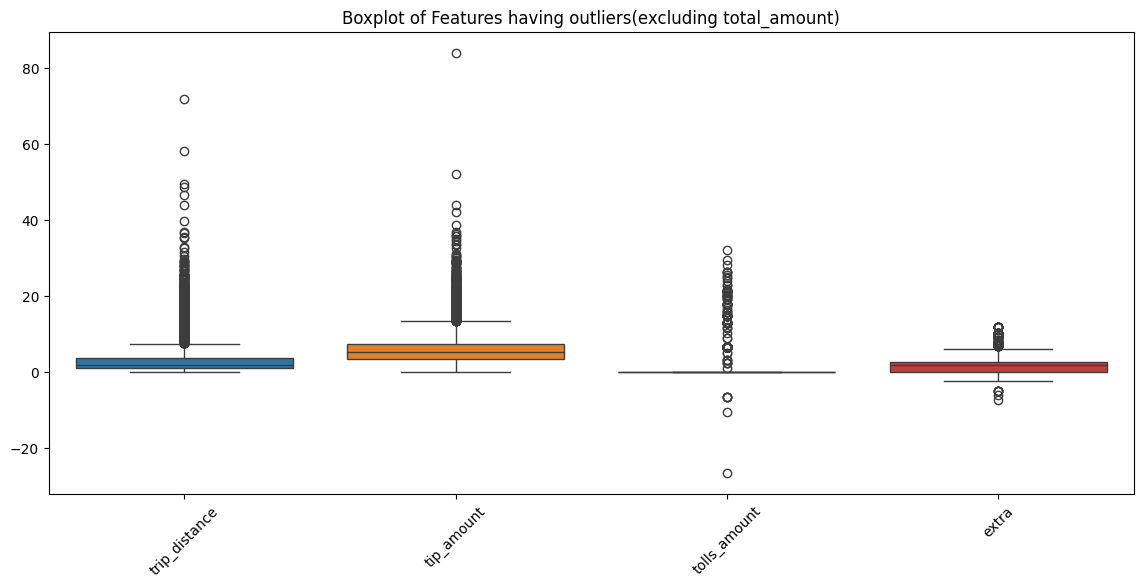

In [329]:
# Removing cols for clearer visualization
if "total_amount" in outlier_cols:
    outlier_cols.remove("total_amount")

plt.figure(figsize = (14, 6))
sns.boxplot(data = train_df[outlier_cols])
plt.xticks(rotation = 45)
plt.title("Boxplot of Features having outliers(excluding total_amount)")
plt.show()

In [330]:
num_cols = train_df.select_dtypes(include=['int64','float64']).columns

negative_counts = {}

for col in num_cols:
    
    # count rows where value is negative
    count = (train_df[col] < 0).sum()
    
    if count > 0:   # store only columns that contain negatives
        negative_counts[col] = count

print("Columns containing negative values:")
pprint(negative_counts)

Columns containing negative values:
{'Airport_fee': np.int64(11),
 'congestion_surcharge': np.int64(85),
 'extra': np.int64(57),
 'improvement_surcharge': np.int64(100),
 'tolls_amount': np.int64(6),
 'total_amount': np.int64(100)}


In [331]:
negative_mask = (train_df[num_cols] < 0).any(axis=1)
rows_with_negative = negative_mask.sum()
print("Rows containing at least one negative value:", rows_with_negative)

Rows containing at least one negative value: 100


In [332]:
train_df = train_df[train_df['total_amount'] >= 0]
negative_mask = (train_df[num_cols] < 0).any(axis=1)
rows_with_negative = negative_mask.sum()
print("Rows containing at least one negative value:", rows_with_negative)

Rows containing at least one negative value: 0


### Handling Negative Values

The dataset initially contained 100 rows with negative values in fare-related features. 
Since negative values are not logically valid for the total trip amount, rows with 
negative `total_amount` were removed from the dataset.

After cleaning, a validation check confirmed that no rows contained negative values 
in the remaining numerical columns. This ensures data consistency and prevents 
unrealistic values from affecting further analysis and model training.

In [333]:
print("Rows after cleaning:", train_df.shape[0])

Rows after cleaning: 9900


# Feature Engineering

In [334]:
# converting the date cols
train_df['tpep_pickup_datetime'] = pd.to_datetime(train_df['tpep_pickup_datetime'])
train_df['tpep_dropoff_datetime'] = pd.to_datetime(train_df['tpep_dropoff_datetime'])

train_df[["tpep_pickup_datetime", "tpep_dropoff_datetime"]].isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
dtype: int64

In [335]:
# converting the categorical cols
categorical_cols = [
    'VendorID',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'store_and_fwd_flag'
]

for col in categorical_cols:
    train_df[col] = train_df[col].astype('category')

In [336]:
train_df['passenger_count'] = train_df['passenger_count'].astype('Int64')

In [337]:
train_df['trip_duration'] = (
    train_df['tpep_dropoff_datetime'] - train_df['tpep_pickup_datetime']
).dt.total_seconds() / 60

train_df[train_df["trip_duration"] < 0].shape

(3793, 18)

### Handling Negative Trip Duration

During feature engineering, 3793 rows were found to have negative trip durations, indicating that the dropoff timestamp was earlier than the pickup timestamp.

Since temporal features such as pickup hour, pickup day, and weekday depend on accurate pickup times, simply taking the absolute duration would not correct the underlying timestamp issue.

Therefore, for rows with negative duration, the pickup and dropoff timestamps were swapped. After swapping, trip duration was recalculated to ensure all values were positive.

This approach preserves temporal consistency and ensures that time-based features derived from pickup timestamps remain accurate.

In [338]:
# Identifing rows with negative duration
mask = train_df["trip_duration"] < 0

# Swaping pickup and dropoff timestamps
train_df.loc[mask, ["tpep_pickup_datetime", "tpep_dropoff_datetime"]] = \
train_df.loc[mask, ["tpep_dropoff_datetime", "tpep_pickup_datetime"]].values

# Recalculating trip duration
train_df["trip_duration"] = (
    train_df["tpep_dropoff_datetime"] - train_df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Verifying the fix
(train_df["trip_duration"] < 0).sum()

np.int64(0)

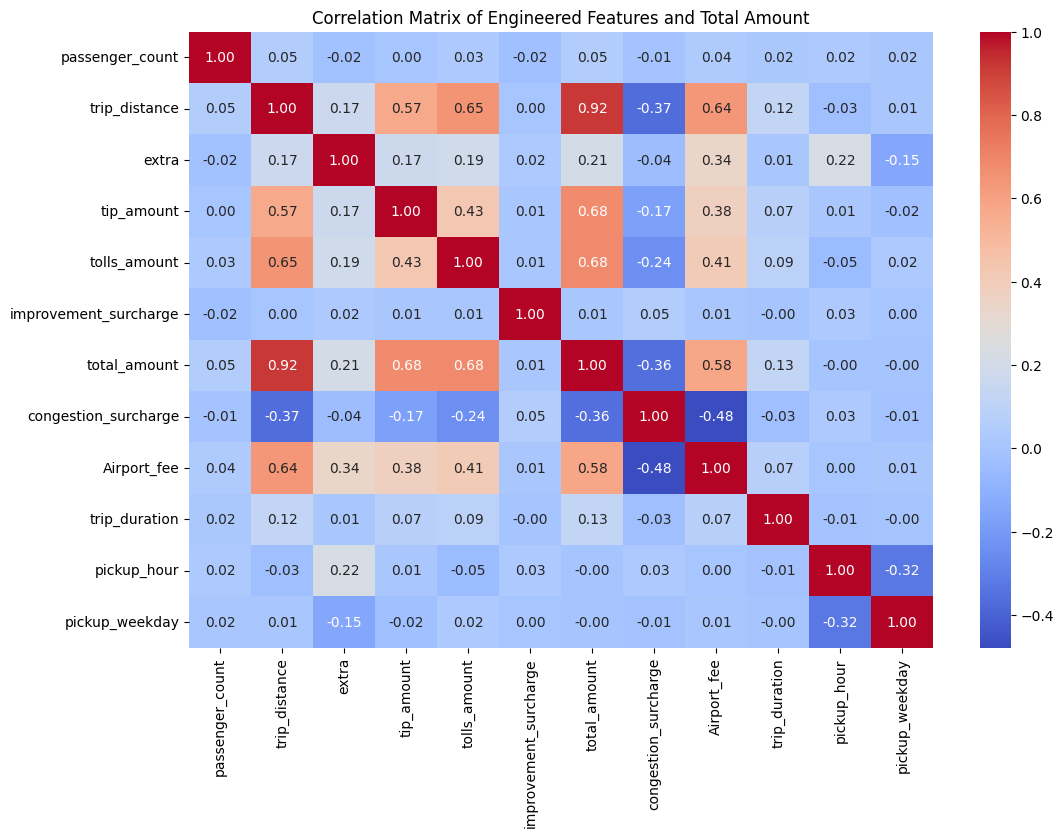

In [339]:
# Pickup hour/day/week features (if not already created)
train_df["pickup_hour"] = train_df["tpep_pickup_datetime"].dt.hour
train_df["pickup_weekday"] = train_df["tpep_pickup_datetime"].dt.weekday

# ---------- Correlation Matrix ----------
corr_matrix = train_df.corr(numeric_only = True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Engineered Features and Total Amount")
plt.show()

In [340]:
train_df.shape

(9900, 20)

# Exploratory Data Analysis (EDA)

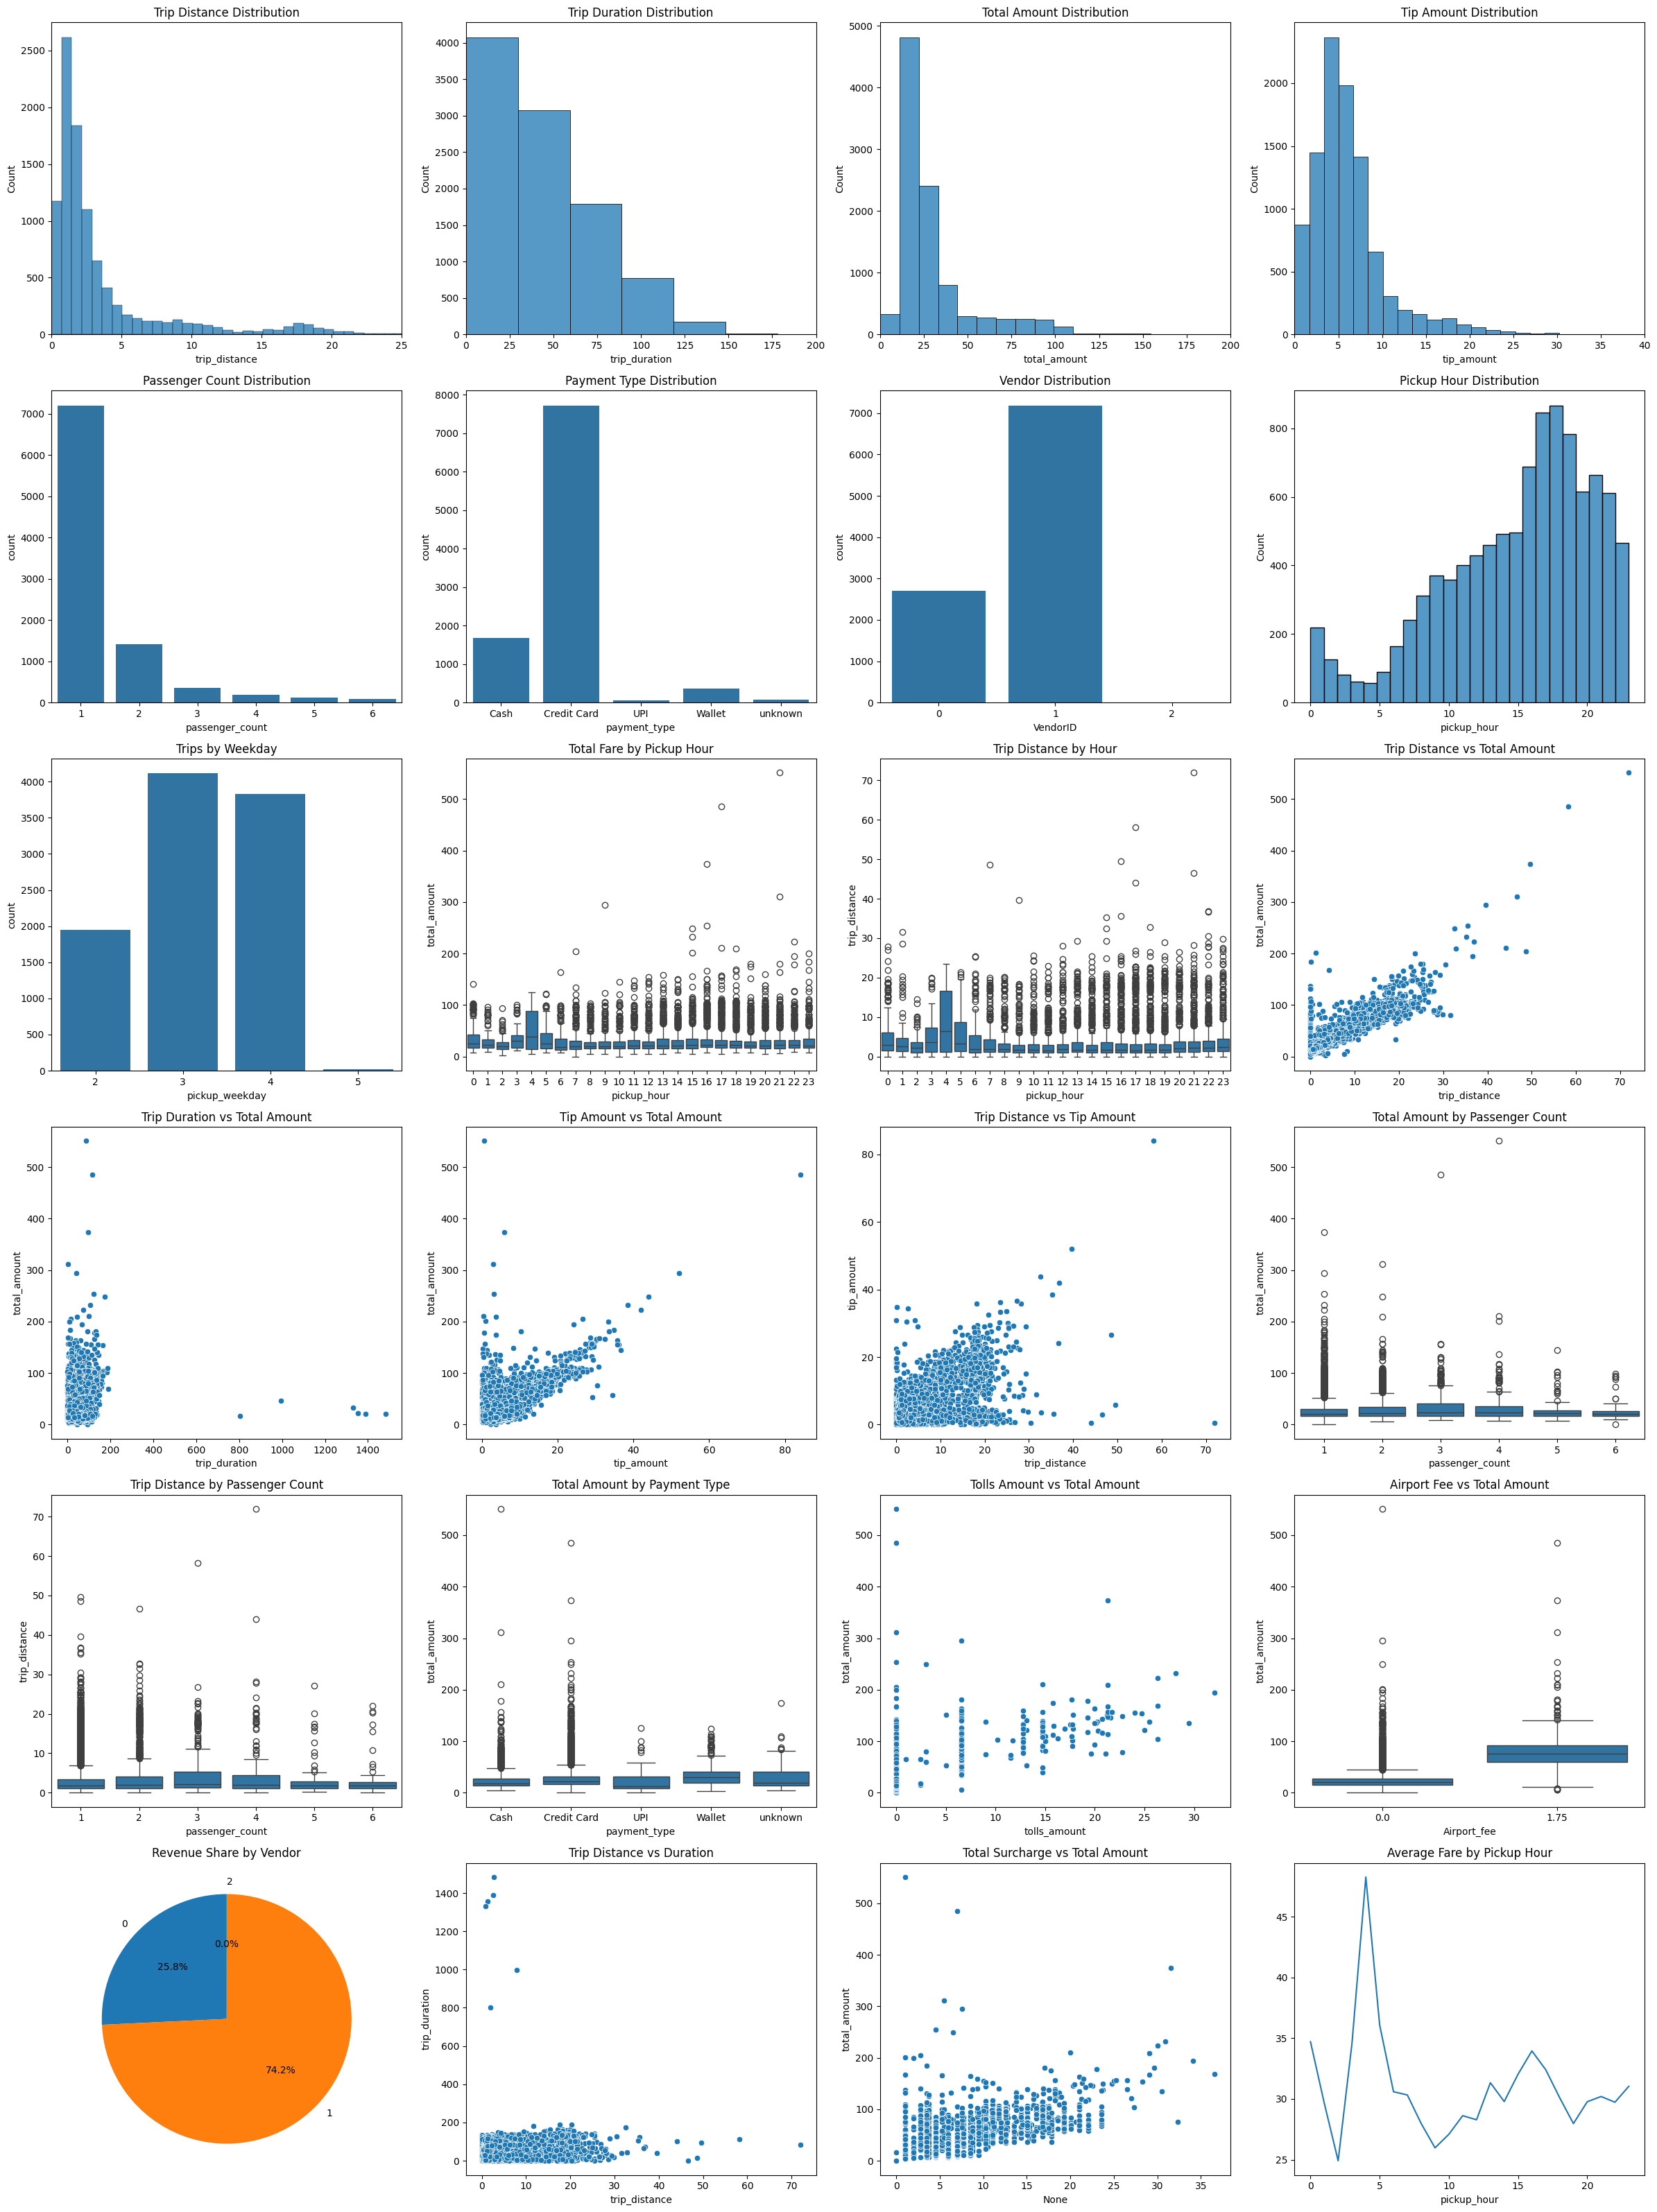

In [341]:
# Create comprehensive EDA visualizations
fig, axes = plt.subplots(6,4, figsize=(24,32))
axes = axes.flatten()

# 1
sns.histplot(train_df["trip_distance"], bins=100, ax=axes[0])
axes[0].set_xlim(0, 25)
axes[0].set_title("Trip Distance Distribution")

# 2
sns.histplot(train_df["trip_duration"], bins=50, ax=axes[1])
axes[1].set_xlim(0, 200)
axes[1].set_title("Trip Duration Distribution")

# 3
sns.histplot(train_df["total_amount"], bins=50, ax=axes[2])
axes[2].set_xlim(0, 200)
axes[2].set_title("Total Amount Distribution")

# 4
sns.histplot(train_df["tip_amount"], bins=50, ax=axes[3])
axes[3].set_xlim(0, 40)
axes[3].set_title("Tip Amount Distribution")

# 5
sns.countplot(x=train_df["passenger_count"], ax=axes[4])
axes[4].set_title("Passenger Count Distribution")

# 6
sns.countplot(x=train_df["payment_type"], ax=axes[5])
axes[5].set_title("Payment Type Distribution")

# 7
sns.countplot(x=train_df["VendorID"], ax=axes[6])
axes[6].set_title("Vendor Distribution")

# 8
sns.histplot(train_df["pickup_hour"], bins=24, ax=axes[7])
axes[7].set_title("Pickup Hour Distribution")

# 9
sns.countplot(x=train_df["pickup_weekday"], ax=axes[8])
axes[8].set_title("Trips by Weekday")

# 10
sns.boxplot(x=train_df["pickup_hour"], y=train_df["total_amount"], ax=axes[9])
axes[9].set_title("Total Fare by Pickup Hour")

# 11
sns.boxplot(x=train_df["pickup_hour"], y=train_df["trip_distance"], ax=axes[10])
axes[10].set_title("Trip Distance by Hour")

# 12
sns.scatterplot(x=train_df["trip_distance"], y=train_df["total_amount"], ax=axes[11])
axes[11].set_title("Trip Distance vs Total Amount")

# 13
sns.scatterplot(x=train_df["trip_duration"], y=train_df["total_amount"], ax=axes[12])
axes[12].set_title("Trip Duration vs Total Amount")

# 14
sns.scatterplot(x=train_df["tip_amount"], y=train_df["total_amount"], ax=axes[13])
axes[13].set_title("Tip Amount vs Total Amount")

# 15
sns.scatterplot(x=train_df["trip_distance"], y=train_df["tip_amount"], ax=axes[14])
axes[14].set_title("Trip Distance vs Tip Amount")

# 16
sns.boxplot(x=train_df["passenger_count"], y=train_df["total_amount"], ax=axes[15])
axes[15].set_title("Total Amount by Passenger Count")

# 17
sns.boxplot(x=train_df["passenger_count"], y=train_df["trip_distance"], ax=axes[16])
axes[16].set_title("Trip Distance by Passenger Count")

# 18
sns.boxplot(x=train_df["payment_type"], y=train_df["total_amount"], ax=axes[17])
axes[17].set_title("Total Amount by Payment Type")

# 19
sns.scatterplot(x=train_df["tolls_amount"], y=train_df["total_amount"], ax=axes[18])
axes[18].set_title("Tolls Amount vs Total Amount")

# 20
sns.boxplot(x=train_df["Airport_fee"], y=train_df["total_amount"], ax=axes[19])
axes[19].set_title("Airport Fee vs Total Amount")

# 21 Vendor Revenue Share (Pie Chart)

vendor_revenue = train_df.groupby("VendorID")["total_amount"].sum()

axes[20].pie(
    vendor_revenue,
    labels=vendor_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[20].set_title("Revenue Share by Vendor")
# 22
sns.scatterplot(x=train_df["trip_distance"], y=train_df["trip_duration"], ax=axes[21])
axes[21].set_title("Trip Distance vs Duration")

# 23
x = (
    train_df["extra"] +
    train_df["tolls_amount"] +
    train_df["improvement_surcharge"] +
    train_df["congestion_surcharge"] +
    train_df["Airport_fee"]
)

sns.scatterplot(x=x, y=train_df["total_amount"], ax=axes[22])
axes[22].set_title("Total Surcharge vs Total Amount")

# 24 Correlation Heatmap
sns.lineplot(
    x=train_df.groupby("pickup_hour")["total_amount"].mean().index,
    y=train_df.groupby("pickup_hour")["total_amount"].mean().values
)
axes[23].set_title("Average Fare by Pickup Hour")

plt.tight_layout()
plt.show()

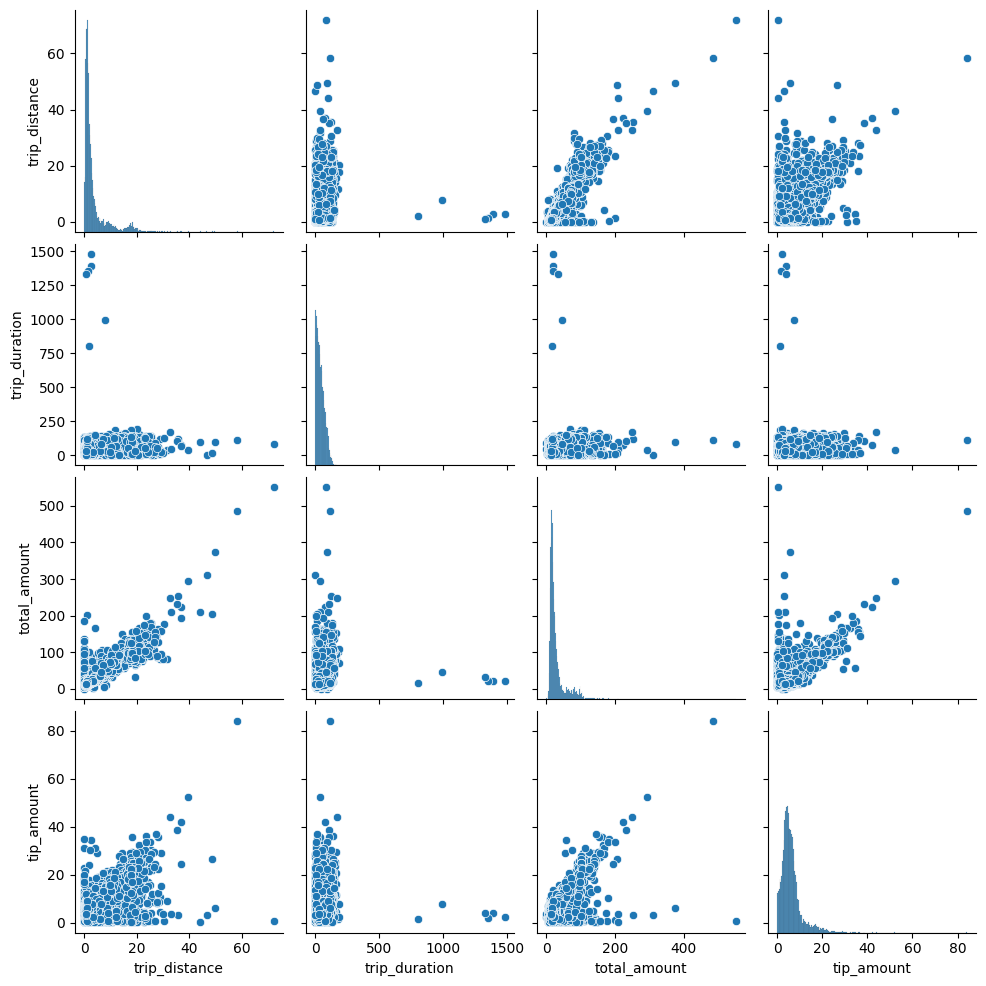

In [342]:
sns.pairplot(
    train_df[[
        "trip_distance",
        "trip_duration",
        "total_amount",
        "tip_amount"
    ]]
)


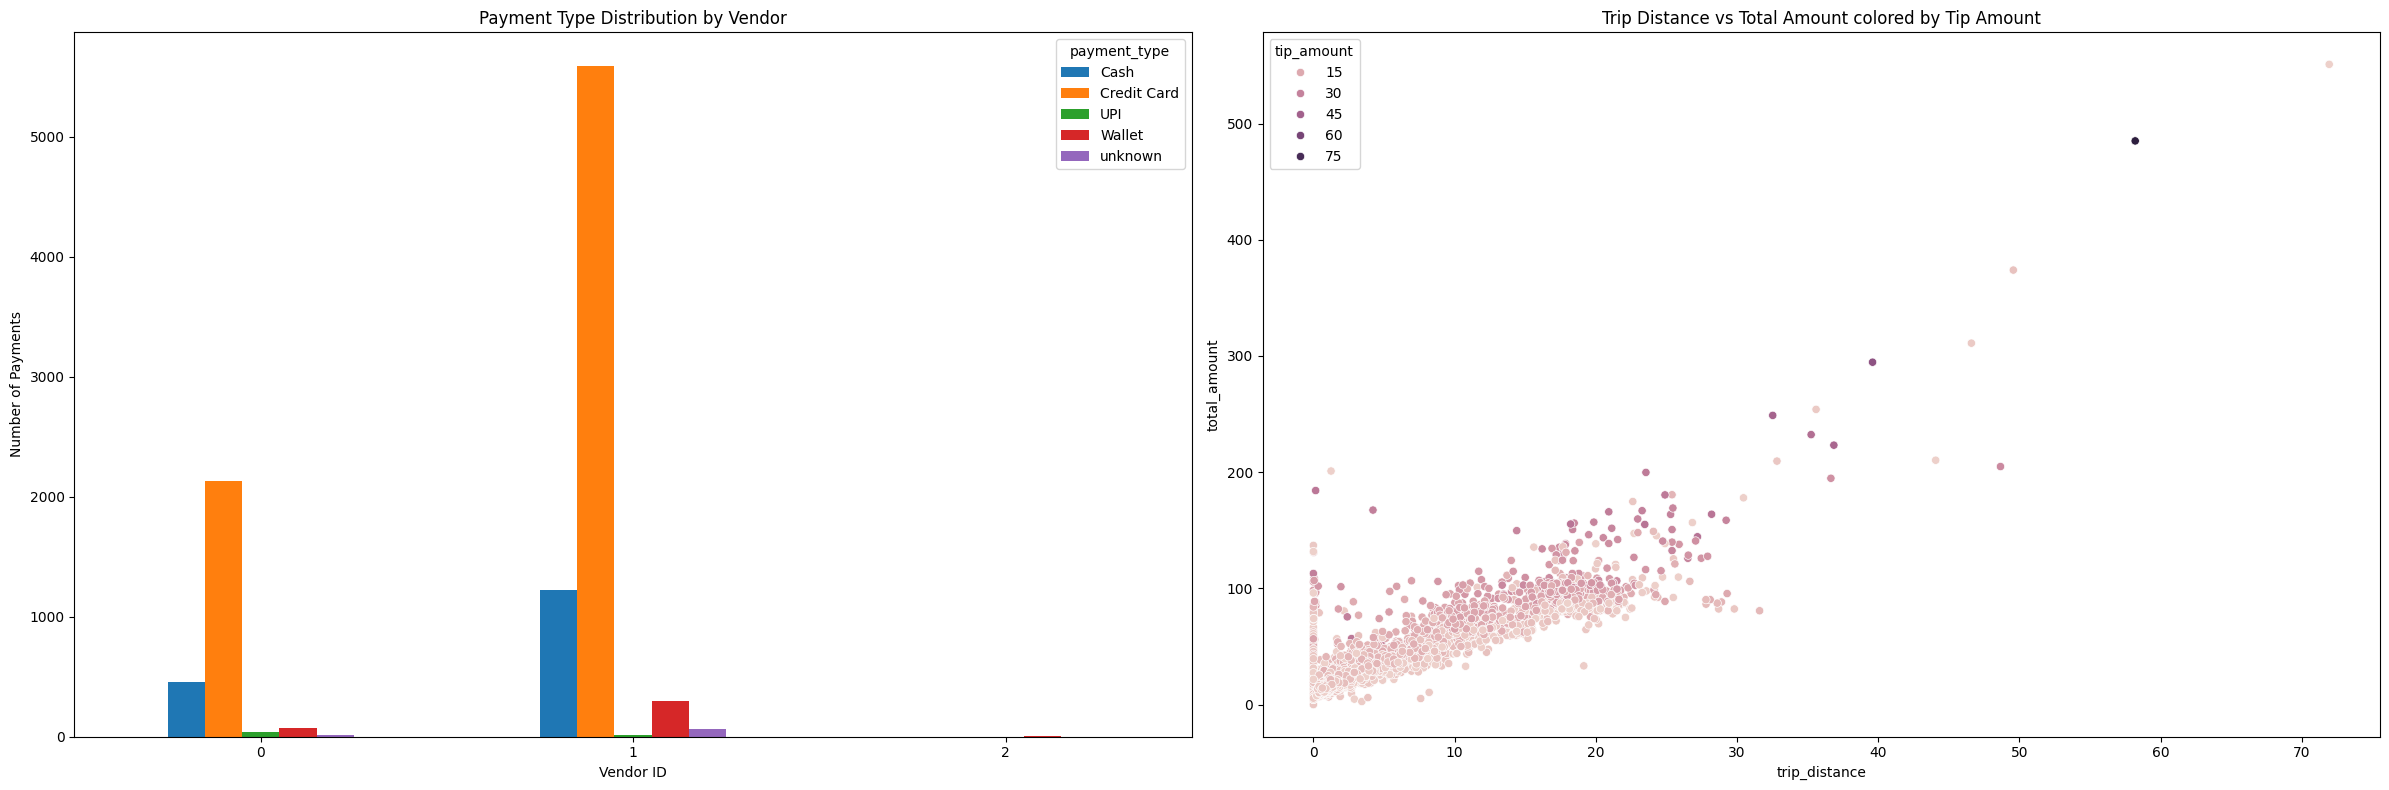

In [343]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# ---- Plot 1: Bar plot ----
vendor_payment_counts = train_df.groupby(['VendorID', 'payment_type']).size().unstack(fill_value=0)
vendor_payment_counts.plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_xlabel("Vendor ID")
axes[0].set_ylabel("Number of Payments")
axes[0].set_title("Payment Type Distribution by Vendor")
axes[0].tick_params(axis='x', rotation=0)


# ---- Plot 2: Scatter plot ----
sns.scatterplot(
    data=train_df,
    x="trip_distance",
    y="total_amount",
    hue="tip_amount",
    ax=axes[1]
)
axes[1].set_title("Trip Distance vs Total Amount colored by Tip Amount")

plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA) Observations

### 1. Trip Distance
- The distribution of trip distance is **highly right-skewed**.
- Most trips are **short (0–5 miles)**.
- Very few trips exceed **20 miles**, indicating long trips are rare.
- Presence of **0 distance trips** suggests possible data entry issues or cancelled trips.

### 2. Trip Duration
- Trip duration is also **right-skewed**, with most trips lasting **0–100 minutes**.
- A few extreme values (>1000 minutes) appear as **outliers**, likely data anomalies.

### 3. Total Amount
- The total fare distribution is **right-skewed**.
- Most fares fall between **10  and  50**.
- Some trips exceed **200–500**, which may correspond to long-distance or premium trips.

### 4. Tip Amount
- Tips mostly fall between **2 and 10**.
- The distribution is **positively skewed**, with a few high tips (> $30).
- Tip amounts increase with higher total fares.

### 5. Passenger Count
- The majority of trips have **1 passenger (~73%)**.
- Passenger counts above **3 are uncommon**.
- Some trips have **0 passengers**, which may indicate missing or incorrect data.

### 6. Payment Type
- **Credit Card dominates (~77%)**, indicating most customers prefer digital payments.
- **Cash (~17%)** is the second most common payment method.
- Wallet, UPI, and unknown methods are used very rarely.

### 7. Vendor Distribution
- Vendor 1 handles about **74% of the trips**, while Vendor 0 accounts for **~26%**.
- Vendor 2 appears only once, suggesting **data inconsistency or rare usage**.

### 8. Pickup Hour Patterns
- Trip pickups increase gradually throughout the day.
- Peak demand occurs during **evening hours (17:00–20:00)**.
- Very low activity occurs during **late night / early morning (1–5 AM)**.

### 9. Trips by Weekday
- Trips are **more frequent on weekdays**, especially midweek.
- Weekend trips are comparatively lower.

### 10. Relationship: Trip Distance vs Total Amount
- There is a **strong positive correlation**.
- As trip distance increases, the total fare increases.

### 11. Relationship: Trip Duration vs Total Amount
- Weak to moderate correlation.
- Some trips have **very long duration but relatively low fare**, likely due to traffic delays or data anomalies.

### 12. Relationship: Tip Amount vs Total Amount
- Strong positive relationship.
- Higher fares tend to receive **higher tips**, suggesting tipping may be **percentage-based**.

### 13. Relationship: Trip Distance vs Tip Amount
- Moderate positive correlation.
- Longer trips generally result in larger tips.

### 14. Passenger Count vs Total Amount
- Passenger count has **minimal impact on total fare**.
- Fares appear primarily influenced by **distance and surcharges rather than passenger number**.

### 15. Trip Distance vs Passenger Count
- No clear relationship observed.
- Trips of all distances occur across different passenger counts.

### 16. Payment Type vs Total Amount
- Trips paid by **credit card show slightly higher total fares**, likely because tipping is easier digitally.

### 17. Tolls Amount vs Total Amount
- Clear positive relationship.
- Trips with tolls have **significantly higher total fares**.

### 18. Airport Fee vs Total Amount
- Trips with an **airport fee ($1.75)** tend to have **higher total fares**, likely due to airport pickups/drop-offs.

### 19. Total Surcharge vs Total Amount
- A positive correlation exists.
- Higher surcharges contribute directly to higher final fares.

### 20. Trip Distance vs Trip Duration
- Positive relationship exists but **not perfectly linear**.
- Some trips show long duration with short distance, possibly due to **traffic congestion or waiting time**.

### 21. Average Fare by Pickup Hour
- Early morning fares are relatively **higher**, possibly due to airport trips or low supply.
- Midday fares are more stable.
- Slight increase during **evening rush hours**.

### 22. General Data Quality Observations
- Some **negative values** appear in tolls, surcharges, and airport fees, which may represent **refunds or corrections**.
- Outliers exist in **trip duration and total amount**, which may need to be handled during modeling.

### Overall Insights
- **Trip distance is the strongest predictor of total fare.**
- **Credit card is the dominant payment method.**
- **Most taxi rides are short, single-passenger trips.**
- Demand peaks during **evening hours and weekdays**.
- Several **outliers and possible data errors** should be cleaned before building predictive models.

# Preprocessing

In [344]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9900 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               9900 non-null   category      
 1   tpep_pickup_datetime   9900 non-null   datetime64[ns]
 2   tpep_dropoff_datetime  9900 non-null   datetime64[ns]
 3   passenger_count        9361 non-null   Int64         
 4   trip_distance          9900 non-null   float64       
 5   RatecodeID             9534 non-null   category      
 6   store_and_fwd_flag     9534 non-null   category      
 7   PULocationID           9900 non-null   category      
 8   DOLocationID           9900 non-null   category      
 9   payment_type           9900 non-null   category      
 10  extra                  9900 non-null   float64       
 11  tip_amount             9900 non-null   float64       
 12  tolls_amount           9900 non-null   float64       
 13  improvem

In [345]:
# Feature Groups
num_features = [
    "trip_distance",
    "extra",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "trip_duration",
    "pickup_hour",
    "pickup_weekday"
]

cat_features = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "payment_type"
]

special_features = [
    "passenger_count",
    "congestion_surcharge",
    "Airport_fee"
]

In [346]:
# Special Imputation
passenger_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
])

ratecode_pipeline = Pipeline([
    ("replace_99", FunctionTransformer(
        lambda x: x.replace(99, 0)
    )),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

store_flag_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

surcharge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
])

airport_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
])


# Numerical Pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Column Transformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
    ("passenger", passenger_pipeline, ["passenger_count"]),
    ("congestion", surcharge_pipeline, ["congestion_surcharge"]),
    ("airport", airport_pipeline, ["Airport_fee"])
])

# Final Pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor)
])

pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trip_distance', 'extra',
                                                   'tip_amount', 'tolls_amount',
                                                   'improvement_surcharge',
                                                   'trip_duration',
                                                   'pickup_hour',
                                                   'pickup_weekday']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='mos...
                                                   'payment_type']),
                                                 ('passenger',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['passenger_count']),
                                                 ('congestion',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['congestion_surcharge']),
                                                 ('airport',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                                  ['Airport_fee'])]))])

In [347]:
# Features and target
X = train_df.drop(columns=["total_amount"])
y = train_df["total_amount"]

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)

print("Validation shape:", X_val.shape, y_val.shape)

Train shape: (7920, 19) (7920,)
Validation shape: (1980, 19) (1980,)


In [348]:
# Transforming train and validation datasets
X_train_transformed = pipeline.fit_transform(X_train)
X_val_transformed = pipeline.transform(X_val)

In [349]:
X_train_transformed.shape

(7920, 555)

In [350]:
X_head = pd.DataFrame(
    X_train_transformed[:5].toarray(),
    columns=pipeline.named_steps["preprocessing"].get_feature_names_out()
)

X_head

,num__trip_distance,num__extra,num__tip_amount,num__tolls_amount,num__improvement_surcharge,num__trip_duration,num__pickup_hour,num__pickup_weekday,cat__VendorID_0,cat__VendorID_1,...,cat__DOLocationID_263,cat__DOLocationID_264,cat__payment_type_Cash,cat__payment_type_Credit Card,cat__payment_type_UPI,cat__payment_type_Wallet,cat__payment_type_unknown,passenger__passenger_count,congestion__congestion_surcharge,airport__Airport_fee
0,1.147990,-1.023428,1.620822,2.421168,0.024739,-0.047216,-1.425960,1.092278,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.00
1,2.005491,0.273730,4.149455,-0.276114,0.024739,-0.521660,0.165286,1.092278,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.75
2,-0.505763,0.273730,-0.871877,-0.276114,0.024739,-0.147080,-0.011519,1.092278,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,2.5,0.00
3,-0.599680,0.273730,-0.657113,-0.276114,0.024739,-0.669809,0.342091,-0.254995,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.0,2.5,0.00
4,-0.399596,0.273730,-0.419828,-0.276114,0.024739,0.148487,-1.072350,-0.254995,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.5,0.00


# Machine Learning

## Model fitting

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_transformed, y_train)

# Ridge
ridge = Ridge()
ridge.fit(X_train_transformed, y_train)

# Lasso
lasso = Lasso()
lasso.fit(X_train_transformed, y_train)

# SGD Regressor
sgd = SGDRegressor(random_state=RANDOM_STATE)
sgd.fit(X_train_transformed, y_train)

# K Nearest Neighbors (k=5)
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_transformed, y_train)

# Decision Tree
dtr = DecisionTreeRegressor(random_state=RANDOM_STATE)
dtr.fit(X_train_transformed, y_train)

# Random Forest
rf = RandomForestRegressor(random_state=RANDOM_STATE)
rf.fit(X_train_transformed, y_train)

# Gradient Boosting
gbr = GradientBoostingRegressor(random_state=RANDOM_STATE)
gbr.fit(X_train_transformed, y_train)

# Bagging Regressor
bag = BaggingRegressor(random_state=RANDOM_STATE)
bag.fit(X_train_transformed, y_train)

# MLP Regressor
mlp = MLPRegressor(random_state=RANDOM_STATE, max_iter=500)
mlp.fit(X_train_transformed, y_train)

# Model Performance

In [ ]:
# Store models in a dictionary
models = {
    "LinearRegression": lr,
    "Ridge": ridge,
    "Lasso": lasso,
    "SGDRegressor": sgd,
    "KNeighborsRegressor": knn,
    "DecisionTreeRegressor": dtr,
    "RandomForestRegressor": rf,
    "GradientBoostingRegressor": gbr,
    "BaggingRegressor": bag,
    "MLPRegressor": mlp
}

model_names = []
r2_scores = []

# Predict and collect R2 scores
for name, model in models.items():
    y_pred = model.predict(X_val_transformed)
    r2 = r2_score(y_val, y_pred)
    
    print(f"{name}: R2 = {r2:.4f}")
    
    model_names.append(name)
    r2_scores.append(r2)

# Identify top 3 models
top3_idx = np.argsort(r2_scores)[-3:]

# Assign colors
colors = ["skyblue"] * len(r2_scores)
for i in top3_idx:
    colors[i] = "green"

# Plot graph
plt.figure(figsize=(12,6))
bars = plt.bar(model_names, r2_scores, color=colors)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Performance Comparison (Top 3 Highlighted)")
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Model Performance Discussion

Among all the models tested, the **ensemble tree-based models performed the best**.  
The top model was **BaggingRegressor**, achieving an **R² score of 0.9435**, which means the model is able to explain about **94.35% of the variance** in the taxi fare (`total_amount`). This indicates that the model captures the relationship between the input features and the target variable very effectively.

Closely following BaggingRegressor were **RandomForestRegressor (R² = 0.9426)** and **GradientBoostingRegressor (R² = 0.9415)**. Both of these are ensemble learning methods that combine multiple decision trees to improve prediction accuracy. Their strong performance suggests that the dataset contains **non-linear relationships**, which tree-based ensemble models are particularly good at capturing.

The **DecisionTreeRegressor** also performed well with an **R² score of 0.9323**, but slightly lower than the ensemble models. This is expected because ensemble techniques like bagging and random forests reduce variance and improve generalization compared to a single decision tree.

Although **linear models** such as LinearRegression, Ridge, and SGDRegressor produced solid results (around **R² ≈ 0.92**), they still performed slightly worse than the ensemble tree models. This indicates that while the dataset does have a strong linear component, **non-linear patterns also play an important role** in predicting taxi fares.

Overall, the results show that **ensemble tree-based models are the most effective choice for this problem**, with BaggingRegressor, RandomForestRegressor, and GradientBoostingRegressor providing the highest predictive performance.

## Top 3 Performing Models

Based on the **R² scores obtained from the validation set**, the following models achieved the best performance:

1. **BaggingRegressor** — R² = **0.9435**  
2. **RandomForestRegressor** — R² = **0.9426**  
3. **GradientBoostingRegressor** — R² = **0.9415**

These models are all **ensemble-based tree models**, which combine multiple decision trees to improve predictive accuracy and reduce overfitting. Their superior performance suggests that the relationship between the input features and the taxi fare contains **non-linear patterns**, which ensemble methods are particularly effective at capturing.

Among them, **BaggingRegressor** performed the best, explaining approximately **94.35% of the variance** in the target variable (`total_amount`).

# Hyper Parameter Tuning

In [ ]:
# RandomForestRegressor
rf_params = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    rf_params,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_search.fit(X_train_transformed, y_train)

print("Best RF Score:", rf_search.best_score_)
print("Best RF Params:", rf_search.best_params_)

In [ ]:
# GradientBoostingRegressor
gbr_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "subsample": [0.8, 0.9, 1.0]
}

gbr_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gbr_params,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

gbr_search.fit(X_train_transformed, y_train)

print("Best GBR Score:", gbr_search.best_score_)
print("Best GBR Params:", gbr_search.best_params_)

In [ ]:
bag_params = {
    "n_estimators": [10, 20, 50, 100],
    "max_samples": [0.5, 0.7, 1.0],
    "max_features": [0.5, 0.7, 1.0],
    "bootstrap": [True, False]
}

bag_search = RandomizedSearchCV(
    BaggingRegressor(random_state=RANDOM_STATE),
    bag_params,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

bag_search.fit(X_train_transformed, y_train)

print("Best Bagging Score:", bag_search.best_score_)
print("Best Bagging Params:", bag_search.best_params_)

In [ ]:
best_rf = rf_search.best_estimator_
best_gbr = gbr_search.best_estimator_
best_bag = bag_search.best_estimator_

models = {
    "RandomForest (Tuned)": best_rf,
    "GradientBoosting (Tuned)": best_gbr,
    "Bagging (Tuned)": best_bag
}

pprint(models)

for name, model in models.items():
    y_pred = model.predict(X_val_transformed)
    r2 = r2_score(y_val, y_pred)
    print(f"{name}: R2 = {r2:.4f}")

## Hyperparameter Tuning Results

After performing hyperparameter tuning on the top three models — **RandomForestRegressor**, **GradientBoostingRegressor**, and **BaggingRegressor** — the models were re-evaluated on the validation dataset using the **R² metric**.

### Tuned Model Performance

| Model | R² Score |
|------|------|
| GradientBoostingRegressor (Tuned) | **0.9506** |
| BaggingRegressor (Tuned) | **0.9422** |
| RandomForestRegressor (Tuned) | **0.8933** |

### Observations

The **GradientBoostingRegressor** achieved the best performance after tuning, with an **R² score of 0.9506**, meaning it explains approximately **95.06% of the variance** in the taxi fare (`total_amount`). This indicates that the tuned boosting model was able to capture complex patterns in the dataset very effectively.

The **BaggingRegressor** also maintained strong performance with an **R² score of 0.9422**. Bagging works by training multiple models on different bootstrap samples of the dataset and averaging their predictions, which helps reduce variance and improve stability.

Interestingly, the **RandomForestRegressor** showed a decrease in performance after tuning, achieving an **R² score of 0.8933**, which is lower than its earlier baseline performance. This can happen when the selected hyperparameters restrict the model too much or are not optimal for the dataset.

### Key Insight

Overall, the results show that **Gradient Boosting is the most effective model for this problem after tuning**, likely because boosting methods sequentially learn from previous errors and are particularly good at modeling complex relationships between features.

Therefore, **GradientBoostingRegressor (Tuned)** can be considered the **best-performing model for predicting taxi fares in this experiment**.

## Voting Regressor

In [ ]:
voting = VotingRegressor(
    estimators=[
        ("rf", best_rf),
        ("gbr", best_gbr),
        ("bag", best_bag)
    ]
)

voting.fit(X_train_transformed, y_train)

# Predict
y_pred_vote = voting.predict(X_val_transformed)

# Score
r2_vote = r2_score(y_val, y_pred_vote)
print("Voting Regressor R2:", r2_vote)

The **Voting Regressor** combines RandomForest, GradientBoosting, and Bagging by averaging their predictions, achieving an **R² score of 0.9415** on the validation set.  
This indicates the ensemble explains about **94.15% of the variance** in the taxi fare predictions.  
However, its performance is slightly lower than the **tuned GradientBoostingRegressor (R² = 0.9506)**, which remains the best individual model.

## Stacking Regressor

In [ ]:
stack = StackingRegressor(
    estimators=[
        ("rf", best_rf),
        ("gbr", best_gbr),
        ("bag", best_bag)
    ],
    final_estimator=Ridge()
)

stack.fit(X_train_transformed, y_train)

# Predict
y_pred_stack = stack.predict(X_val_transformed)

# Score
r2_stack = r2_score(y_val, y_pred_stack)
print("Stacking Regressor R2:", r2_stack)

The Stacking Regressor achieved an **R² score of 0.9493**, indicating that it explains about **94.93% of the variance** in the taxi fare predictions.  
This performance is very close to the best individual model, **GradientBoostingRegressor**, showing that combining multiple models can produce strong and stable predictions.  
Stacking works by using the predictions of several base models and learning how to optimally combine them through a final meta-model.

# Test data preprocessing

In [ ]:
if "id" in test_df.columns: test_df = test_df.drop("id", axis = 1)
# Replace passenger_count 0 with NaN
test_df["passenger_count"] = test_df["passenger_count"].replace(0, np.nan)

# Convert datetime columns
test_df["tpep_pickup_datetime"] = pd.to_datetime(test_df["tpep_pickup_datetime"])
test_df["tpep_dropoff_datetime"] = pd.to_datetime(test_df["tpep_dropoff_datetime"])

# Feature Engineering (same as train)
test_df["trip_duration"] = (
    test_df["tpep_dropoff_datetime"] - test_df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

test_df["pickup_hour"] = test_df["tpep_pickup_datetime"].dt.hour
test_df["pickup_weekday"] = test_df["tpep_pickup_datetime"].dt.weekday

# Convert categorical columns
categorical_cols = [
    "VendorID",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "store_and_fwd_flag"
]

for col in categorical_cols:
    test_df[col] = test_df[col].astype("category")

# Convert passenger_count dtype
test_df["passenger_count"] = test_df["passenger_count"].astype("Int64")

# Replace RatecodeID 99 → 0 (same cleaning rule used in training)
test_df["RatecodeID"] = test_df["RatecodeID"].replace(99, 0)

# Apply sklearn preprocessing pipeline
X_test_transformed = pipeline.transform(test_df)

# Convert sparse matrix to DataFrame with same feature names
feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()

X_test_transformed = pd.DataFrame(
    X_test_transformed.toarray(),
    columns=feature_names
)

# Verify column count (should match training = 555)
print(X_test_transformed.shape)

X_test_transformed.head()

In [ ]:
# Predict
y_pred = stack.predict(X_test_transformed)

submission = pd.DataFrame({
    'id' : range(X_test_transformed.shape[0]),
    'total_amount' : y_pred
})

#submitting
submission.to_csv(SUBMISSION_CSV_PATH, index = False)